In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [5]:
df=pd.read_csv('../data/height-weight.csv')

In [6]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

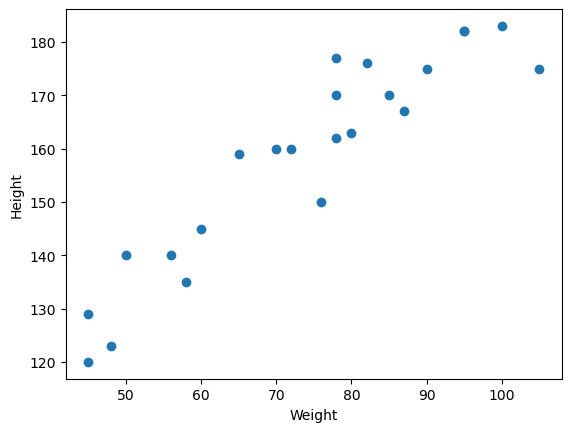

In [7]:
##scatter plot
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [8]:
##finding correlation
df.corr(numeric_only=True)

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


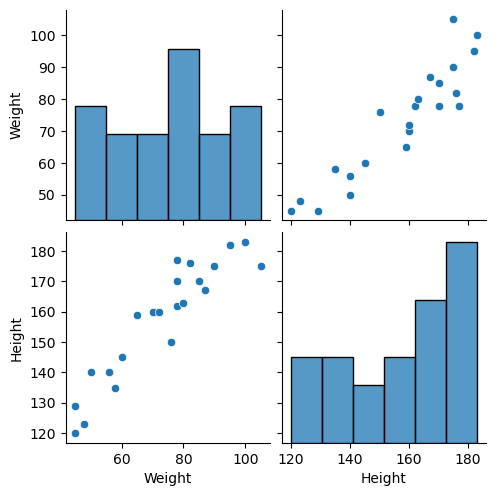

In [9]:
##seaborn for visualization
import seaborn as sns
sns.pairplot(df)

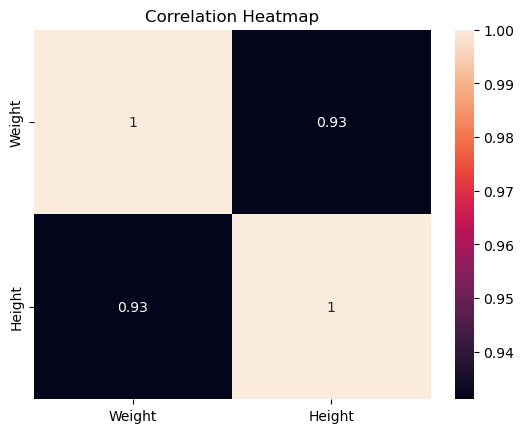

In [10]:
import seaborn as sns

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)
plt.title("Correlation Heatmap")
plt.show()

In [11]:
##Indepedent and dependent features
X = df[['Weight']] ##independent featutes should be data frame or 2 dimensional array
y = df['Height'] ## this var can be in series or 1d array
np.array(X) ##OR we can just type X to see the df

array([[ 45],
       [ 58],
       [ 48],
       [ 60],
       [ 70],
       [ 78],
       [ 80],
       [ 90],
       [ 95],
       [ 78],
       [ 82],
       [ 95],
       [105],
       [100],
       [ 85],
       [ 78],
       [ 50],
       [ 65],
       [ 76],
       [ 87],
       [ 45],
       [ 56],
       [ 72]])

In [12]:
X_series=df['Weight']
np.array(X_series).shape

(23,)

In [13]:
np.array(y).shape

(23,)

In [14]:
##Train test split

from sklearn.model_selection import train_test_split


In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25)

In [16]:
##stadartization

from sklearn.preprocessing import StandardScaler

In [17]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)

In [18]:
X_test = scaler.transform(X_test)

In [19]:
##Apply Simple linear Regression
from sklearn.linear_model import LinearRegression

In [20]:
regression=LinearRegression(n_jobs=-1)

In [21]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [22]:
print("Coefficient or slope:",regression.coef_)
print("Intercept:",regression.intercept_)

Coefficient or slope: [17.49461604]
Intercept: 161.0


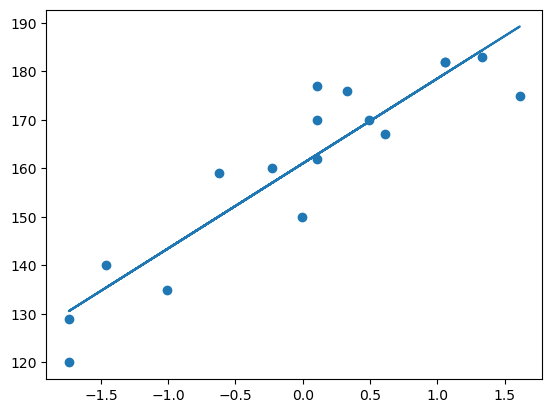

In [23]:
##plot training data plot best fit line
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

In [24]:
##Prediction for test data
y_pred=regression.predict(X_test)

performance metrics


In [25]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

In [27]:
mae = mean_absolute_error(y_test,y_pred)

mse = mean_squared_error(y_test,y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,y_pred)

In [28]:
print("MAE :",mae)
print("MSE :",mse)
print("RMSE :",rmse)
print("R2 Score :",r2)

MAE : 3.2191508659784964
MSE : 23.457293108372255
RMSE : 4.843272974794241
R2 Score : 0.9192056494545158


Residual plot

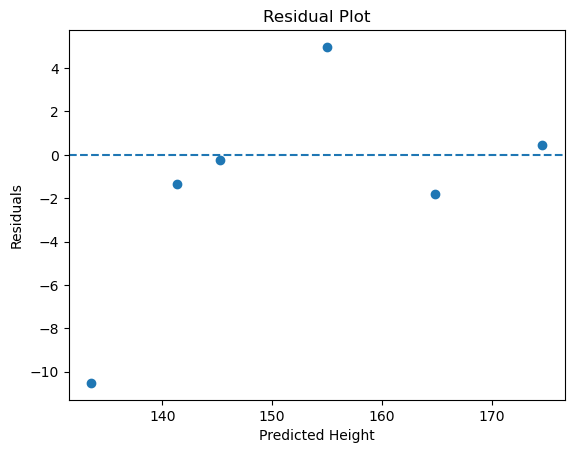

In [30]:
residuals = y_test - y_pred
plt.scatter(
    y_pred,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Height")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

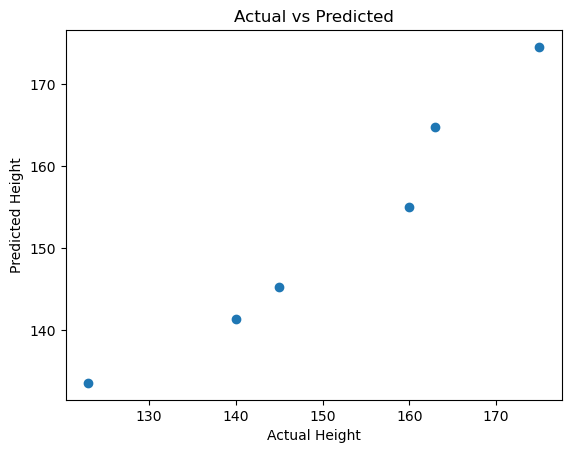

In [32]:
##Actual vs predicted plot

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Height")
plt.ylabel("Predicted Height")

plt.title(
    "Actual vs Predicted"
)

plt.show()

In [33]:
##example prediction

sample_weight = [[70]]

sample_weight = scaler.transform(
    sample_weight
)

prediction = regression.predict(
    sample_weight
)

print(
    "Predicted Height:",
    prediction[0]
)

Predicted Height: 155.02133632790566


c:\Users\Vasihnavee\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
